In [36]:
#Librarynya
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
#Load data
df = pd.read_csv('student_performance.csv')

df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [38]:
#Exploratory Data Analysis (EDA)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278933,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


In [39]:
df['grade'].value_counts()

,count
grade,
A,548644
B,258174
C,141980
D,44998
F,6204


**Memperkecil Data**

In [40]:
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(
    df,
    train_size=10000,
    stratify=df['grade'],
    random_state=42
)

In [41]:
df_sample['grade'].value_counts()

print("Original")
print(df['grade'].value_counts(normalize=True))

print("\nSample")
print(df_sample['grade'].value_counts(normalize=True))

Original
grade
A    0.548644
B    0.258174
C    0.141980
D    0.044998
F    0.006204
Name: proportion, dtype: float64

Sample
grade
A    0.5486
B    0.2582
C    0.1420
D    0.0450
F    0.0062
Name: proportion, dtype: float64


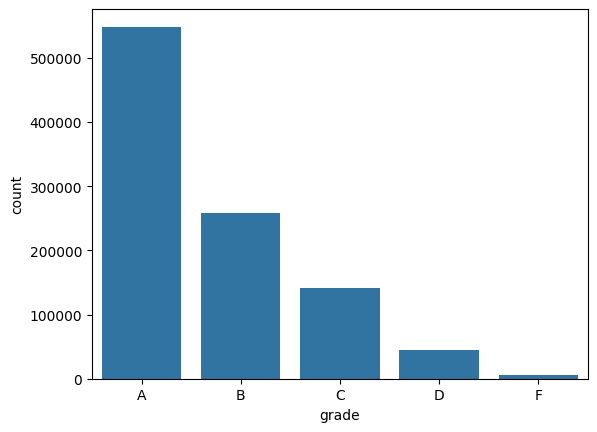

In [42]:
sns.countplot(x='grade', data=df)
plt.show()

In [43]:
df = df.drop('student_id', axis=1)

In [44]:
le = LabelEncoder()

df['grade'] = le.fit_transform(df['grade'])

In [45]:
from sklearn.model_selection import train_test_split

X = df_sample.drop('grade', axis=1)
y = df_sample['grade']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [47]:
import pandas as pd
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

pd.Series(y_train_smote).value_counts()

,count
grade,
C,4389
A,4389
B,4389
D,4389
F,4389


In [48]:
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)

model.fit(X_train_smote, y_train_smote)

GradientBoostingClassifier(max_depth=5)

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder here

rf_model = RandomForestClassifier(
    max_features=2,
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)


gb_model = GradientBoostingClassifier(
    max_features=2,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5
)

gb_model.fit(X_train_smote, y_train_smote)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)


# Apply LabelEncoder to y_train_smote and y_test for XGBoost, as it expects numerical labels
xgb_le = LabelEncoder()
y_train_smote_encoded = xgb_le.fit_transform(y_train_smote)
y_test_encoded = xgb_le.transform(y_test) # Transform y_test using the same encoder

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(xgb_le.classes_), # Use the number of classes from the encoder
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote_encoded)

xgb_pred_encoded = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test_encoded, xgb_pred_encoded)

print("Random Forest     :", rf_accuracy)
print("Gradient Boosting :", gb_accuracy)
print("XGBoost           :", xgb_accuracy)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:41:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Random Forest     : 0.9975
Gradient Boosting : 0.998
XGBoost           : 0.991


In [67]:
print("\nGradient Boosting Report")
print(classification_report(y_test, gb_pred))

print("\nRandom Forest Report")
print(classification_report(y_test, rf_pred))

print("\nXGBoost Report")
print(classification_report(y_test_encoded, xgb_pred_encoded))


Gradient Boosting Report
              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1097
           B       0.99      1.00      1.00       517
           C       1.00      0.99      1.00       284
           D       1.00      1.00      1.00        90
           F       1.00      1.00      1.00        12

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Random Forest Report
              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1097
           B       0.99      1.00      1.00       517
           C       1.00      0.99      1.00       284
           D       1.00      1.00      1.00        90
           F       1.00      1.00      1.00        12

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      

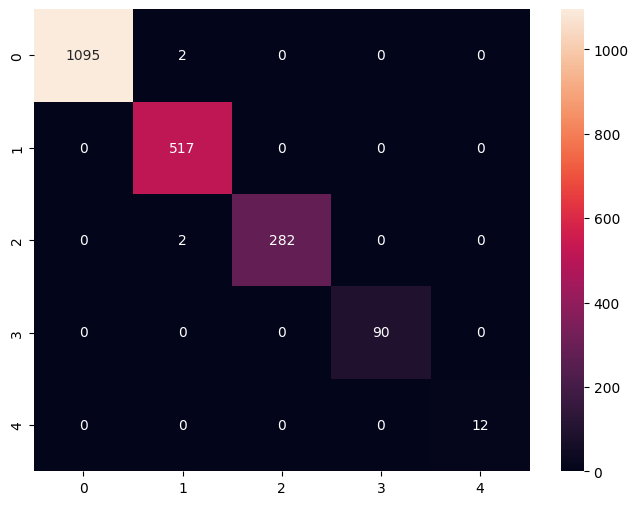

In [68]:
cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [69]:
importance = model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
)

feature_importance.sort_values(ascending=False)

,0
total_score,0.999184
student_id,0.000284
weekly_self_study_hours,0.000206
class_participation,0.000184
attendance_percentage,0.000142


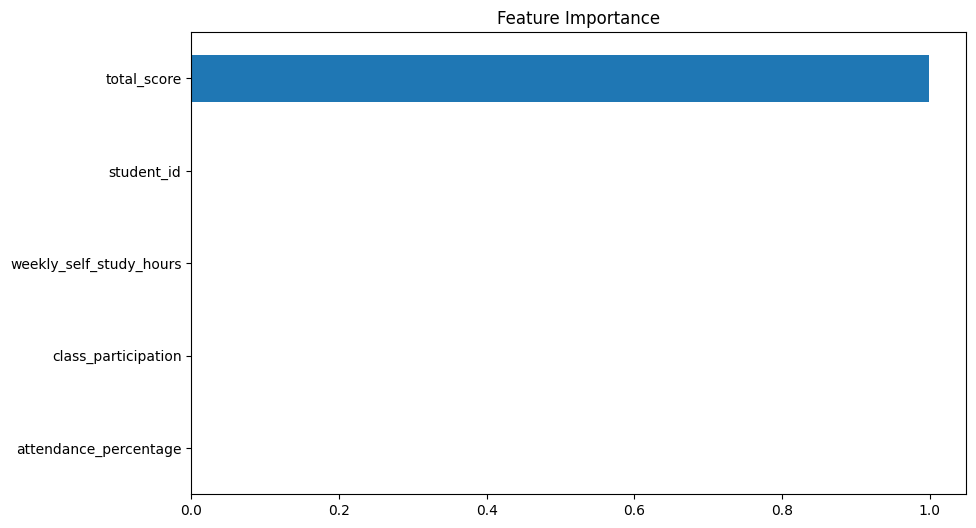

In [70]:
feature_importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.show()

In [71]:
df.corr()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
weekly_self_study_hours,1.000000,-0.001008,0.001244,0.812241,-0.743016
attendance_percentage,-0.001008,1.000000,-0.000043,-0.001014,0.001005
class_participation,0.001244,-0.000043,1.000000,0.000684,-0.000835
total_score,0.812241,-0.001014,0.000684,1.000000,-0.951726
grade,-0.743016,0.001005,-0.000835,-0.951726,1.000000


In [73]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

# ===============================
# Hyperparameter masing-masing model
# ===============================

param_grids = {

    "Random Forest": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": [100,200,300],
            "max_depth": [5,10,15,None],
            "min_samples_split": [2,5,10],
            "min_samples_leaf": [1,2,4]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(),
        "params": {
            "n_estimators": [100,200,300],
            "learning_rate": [0.01,0.05,0.1],
            "max_depth": [3,4,5],
            "subsample": [0.8,0.9,1.0]
        }
    },

    "XGBoost": {
        "model": XGBClassifier(
            objective='multi:softmax',
            # num_class will be set dynamically inside the loop
            eval_metric='mlogloss'
        ),
        "params": {
            "n_estimators": [100,200,300],
            "learning_rate": [0.01,0.05,0.1],
            "max_depth": [3,5,7],
            "subsample": [0.8,1],
            "colsample_bytree": [0.8,1]
        }
    }
}


# ===============================
# Training + Hyperparameter Tuning
# ===============================

best_models = {}
results = {}

# Initialize LabelEncoder for XGBoost outside the loop for consistency
xgb_le_tune = LabelEncoder()
y_train_smote_encoded_tune = xgb_le_tune.fit_transform(y_train_smote)
y_test_encoded_tune = xgb_le_tune.transform(y_test)


for name, mp in param_grids.items():

    print(f"\nTuning {name}...")

    current_X_train = X_train_smote
    current_X_test = X_test

    if name == "XGBoost":
        current_y_train = y_train_smote_encoded_tune
        current_y_test = y_test_encoded_tune
        # Set num_class for the XGBClassifier instance
        mp["model"].set_params(num_class=len(xgb_le_tune.classes_))
    else:
        current_y_train = y_train_smote
        current_y_test = y_test

    search = RandomizedSearchCV(
        mp["model"],
        mp["params"],
        n_iter=10,
        cv=3,
        n_jobs=-1,
        random_state=42
    )

    search.fit(current_X_train, current_y_train)

    best_model = search.best_estimator_

    pred = best_model.predict(current_X_test)

    # Use the appropriate y_test for accuracy calculation
    acc = accuracy_score(current_y_test, pred)

    best_models[name] = best_model
    results[name] = acc

    print(f"Best Parameters {name}:")
    print(search.best_params_)

    print(f"Accuracy {name}: {acc}")


Tuning Random Forest...
Best Parameters Random Forest:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 15}
Accuracy Random Forest: 0.9975

Tuning Gradient Boosting...
Best Parameters Gradient Boosting:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Accuracy Gradient Boosting: 0.9975

Tuning XGBoost...
Best Parameters XGBoost:
{'subsample': 1, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1}
Accuracy XGBoost: 0.993


In [ ]:
import pickle

pickle.dump(best_model, open('model.pkl','wb'))